# d1-4 영업팀 미수금 EDA (기준일 2026-09-30)
- 입력: `demos/d1-4_ar_sales_team_2026-09.xlsx` (원본은 `scripts/read_ar.py`가 읽기만 함, 수정 없음)
- 금액은 원 단위. 차트는 `workbench/day1/outputs/charts/`에 PNG로 저장.
- 숫자는 합성 데이터이며, 판단(충당금·회수 등)은 사람이 합니다.

In [1]:
import sys
from pathlib import Path

# 저장소 맨 위 폴더(pyproject.toml이 있는 곳)로 이동 — 노트북 경로는 저장소 기준
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
import os; os.chdir(root); sys.path.insert(0, str(root))

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scripts.read_ar import read_ar

font_manager.fontManager.addfont("tools/fonts/NanumGothic-Regular.ttf")
plt.rcParams.update({"font.family": "NanumGothic", "axes.unicode_minus": False,
                     "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
pd.options.display.float_format = "{:,.1f}".format
CHART_DIR = Path("workbench/day1/outputs/charts"); CHART_DIR.mkdir(parents=True, exist_ok=True)
BASE = pd.Timestamp("2026-09-30")

df = read_ar()
df.head(3)

,지역,담당,바이어,국가,결제조건_원문,결제조건_코드,인보이스번호,선적일,만기일,선적일_연도추론,만기일_연도추론,금액_원,외화금액,통화,메모,원본시트,원본행,인보이스_중복
0,아시아,영업1팀 A,"Davura Kogyo Co., Ltd.",Japan,O/A 90,OA,INV-2607-0164,2026-07-27,2026-10-25,False,False,"9,897,000.0","1,104,000.0",JPY,NaN,아시아,5,False
1,아시아,영업1팀 A,"Davura Kogyo Co., Ltd.",Japan,사후송금 90일,OA,INV-2608-0003,2026-08-01,2026-10-30,False,False,"23,896,000.0","2,647,000.0",JPY,NaN,아시아,6,False
2,아시아,영업1팀 A,"Davura Kogyo Co., Ltd.",Japan,O/A 90일,OA,INV-2608-0004,2026-08-01,2026-10-30,False,False,"16,710,000.0","1,851,000.0",JPY,NaN,아시아,7,False


## 1) 구조

In [2]:
print(f"행 수: {len(df)}  /  열 수: {df.shape[1]}")
print(f"중복 표시: {int(df['인보이스_중복'].sum())}행 (인보이스 {df.loc[df['인보이스_중복'], '인보이스번호'].nunique()}건)")
pd.DataFrame({"유형": df.dtypes.astype(str), "결측": df.isna().sum()})

행 수: 302  /  열 수: 18
중복 표시: 2행 (인보이스 1건)


,유형,결측
지역,str,0
담당,str,0
바이어,str,0
국가,str,0
결제조건_원문,str,0
결제조건_코드,str,0
인보이스번호,str,0
선적일,datetime64[us],0
만기일,datetime64[us],0
선적일_연도추론,bool,0


## 분석용 표 만들기
- **연체일 = 2026-09-30 − 만기일.** 0 이하는 아직 안 지난 건(미도래)입니다.
- 외화 금액으로 환산한 환율(원화 ÷ 외화)이 같은 통화 중앙값의 10배 넘게 또는 1/10 미만으로 어긋난 행은 **단위 오입력 의심**으로 보고 통계·차트에서 뺍니다(진단 보고서 Q-01의 2건). 원본과 `df`는 그대로 두고, 확인 전이라 값을 고치지는 않습니다.
- 중복 인보이스(INV-2607-0104, 2행)는 표시만 되어 있어 이번에는 **둘 다 포함**합니다(1,962천원, 영향 작음).

In [3]:
df["연체일"] = (BASE - df["만기일"]).dt.days
ratio = (df["금액_원"] / df["외화금액"]) / (df["금액_원"] / df["외화금액"]).groupby(df["통화"]).transform("median")
df["단위의심"] = (ratio > 10) | (ratio < 0.1)
print("제외(단위 의심):")
display(df.loc[df["단위의심"], ["원본시트", "원본행", "바이어", "금액_원", "외화금액", "통화"]])

d = df.loc[~df["단위의심"]].copy()
labels = ["미도래", "1–30", "31–60", "61–90", "90+"]
d["연체구간"] = pd.cut(d["연체일"], [-10**6, 0, 30, 60, 90, 10**6], labels=labels)
overdue = d[d["연체일"] > 0]
print(f"분석 대상 {len(d)}건 / 연체 {len(overdue)}건, 합계 {d['금액_원'].sum():,.0f}원")

제외(단위 의심):


,원본시트,원본행,바이어,금액_원,외화금액,통화
29,아시아,36,PT Quineon Instrumen Nusantara,"1,980,505,000.0","1,460.0",USD
238,유럽·미주,87,Uleon Anlagenbau GmbH,"1,984,531,000.0","1,230.0",EUR


분석 대상 300건 / 연체 46건, 합계 6,313,745,000원


## 2) 기술통계

In [4]:
q = lambda s: s.describe(percentiles=[.25, .5, .75]).rename({"50%": "중앙값(50%)"})[["count", "mean", "min", "25%", "중앙값(50%)", "75%", "max"]]
stat = pd.DataFrame({
    "금액(원) 전체": q(d["금액_원"]),
    "연체일 전체": q(d["연체일"]),
    "연체일 연체 건만": q(overdue["연체일"]),
}).rename(index={"count": "건수", "mean": "평균", "min": "최소", "max": "최대"})
stat

,금액(원) 전체,연체일 전체,연체일 연체 건만
건수,300.0,300.0,46.0
평균,"21,045,816.7",-19.1,80.3
최소,"1,031,000.0",-90.0,3.0
25%,"7,162,250.0",-51.2,14.0
중앙값(50%),"13,247,500.0",-26.0,27.5
75%,"24,454,750.0",-8.0,73.0
최대,"316,582,000.0",381.0,381.0


- 금액은 평균(약 21.0백만원)이 중앙값(약 13.2백만원)보다 커서 큰 건 몇 개가 평균을 끌어올리는 오른쪽 긴 꼬리입니다.
- 연체일 전체는 대부분 음수(미도래)라 평균·사분위수가 마이너스입니다. 연체 건만 보면 중앙값 27.5일, 평균 약 80일입니다.

## 3) 차트

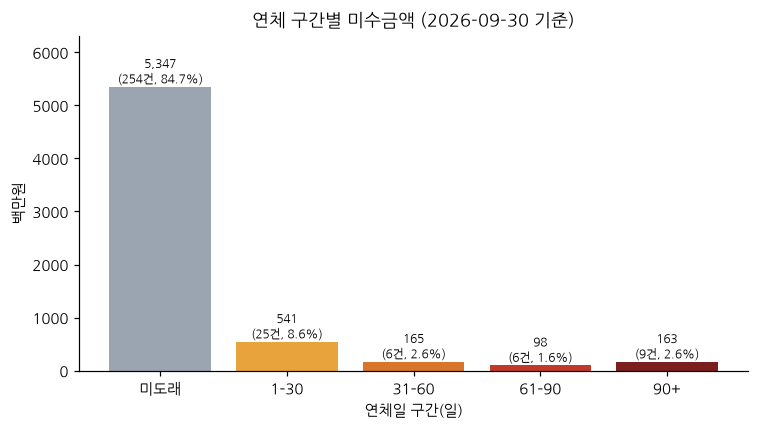

In [5]:
by = d.groupby("연체구간", observed=False)["금액_원"].agg(["sum", "count"])
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#9aa5b1"] + ["#e8a33d", "#d9742b", "#c0392b", "#7b1e1e"]
bars = ax.bar(labels, by["sum"] / 1e6, color=colors)
for b, (s, c) in zip(bars, by.itertuples(index=False)):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{s/1e6:,.0f}\n({c}건, {s/d['금액_원'].sum():.1%})", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, by["sum"].max() / 1e6 * 1.18)
ax.set_title("연체 구간별 미수금액 (2026-09-30 기준)"); ax.set_xlabel("연체일 구간(일)"); ax.set_ylabel("백만원")
fig.tight_layout(); fig.savefig(CHART_DIR / "d1-4_overdue_bucket.png"); plt.show()

- 미수금 6,314백만원 중 84.7%(5,347백만원)는 아직 만기 전이고, 연체는 46건 967백만원(15.3%)입니다.
- 90일 초과 9건(163백만원)은 61–90일 구간(98백만원)보다 크며, 이 9건은 모두 '부도' 메모가 붙은 건입니다.

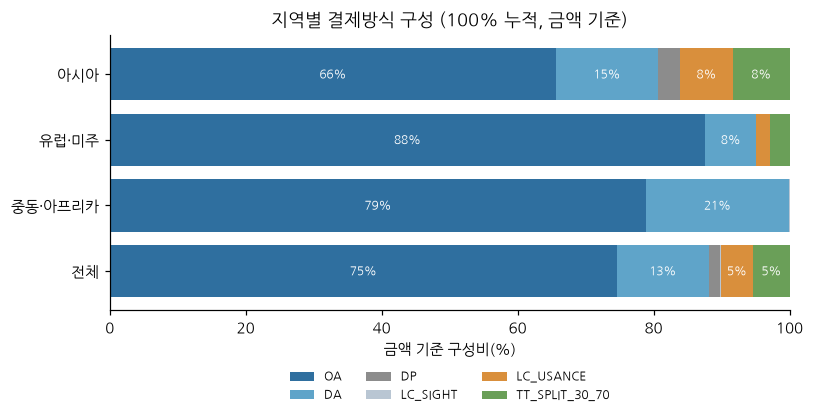

In [6]:
order = ["OA", "DA", "DP", "LC_SIGHT", "LC_USANCE", "TT_SPLIT_30_70"]
mix = d.pivot_table(index="지역", columns="결제조건_코드", values="금액_원", aggfunc="sum", fill_value=0).reindex(columns=order, fill_value=0)
mix.loc["전체"] = mix.sum()
share = mix.div(mix.sum(axis=1), axis=0).loc[["아시아", "유럽·미주", "중동·아프리카", "전체"]]
pal = ["#2f6f9f", "#5fa4c9", "#8c8c8c", "#b9c6d3", "#d98f3c", "#6a9f58"]
fig, ax = plt.subplots(figsize=(7.5, 4))
left = pd.Series(0.0, index=share.index)
for col, c in zip(order, pal):
    ax.barh(share.index, share[col] * 100, left=left * 100, color=c, label=col)
    for y, (v, l) in enumerate(zip(share[col], left)):
        if v >= 0.04: ax.text((l + v / 2) * 100, y, f"{v:.0%}", ha="center", va="center", color="white", fontsize=8)
    left += share[col]
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel("금액 기준 구성비(%)"); ax.set_title("지역별 결제방식 구성 (100% 누적, 금액 기준)")
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False)
fig.tight_layout(); fig.savefig(CHART_DIR / "d1-4_payment_mix.png"); plt.show()

- 금액의 74.6%가 O/A(외상 후 결제)이고, 유럽·미주는 88%로 가장 높습니다. 사후송금도 O/A로 묶은 값이라 담당자 확인 전 수치입니다.
- 아시아는 O/A 66%이고 L/C 기한부·D/P·T/T 분할이 합쳐 약 19%로 결제방식이 가장 다양합니다. 중동·아프리카는 O/A 79%와 D/A 21%가 거의 전부입니다(L/C 일람불 1건은 0.02%).

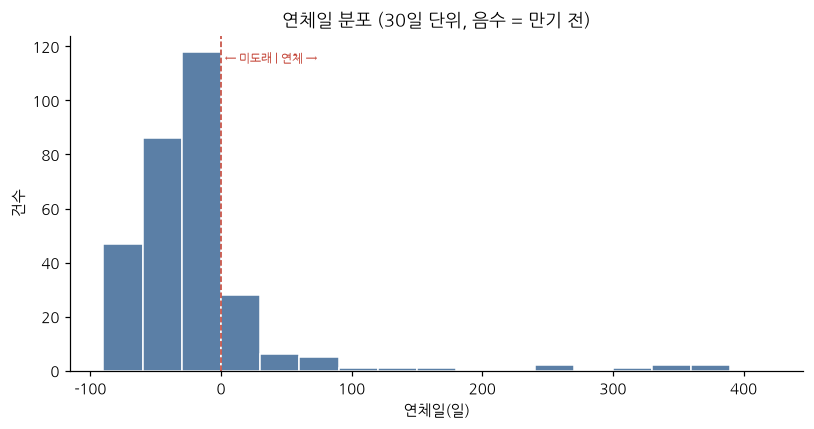

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(d["연체일"], bins=range(-90, 421, 30), color="#5b7fa6", edgecolor="white")
ax.axvline(0, color="#c0392b", ls="--", lw=1); ax.text(3, ax.get_ylim()[1] * 0.92, "← 미도래 | 연체 →", color="#c0392b", fontsize=8)
ax.set_title("연체일 분포 (30일 단위, 음수 = 만기 전)"); ax.set_xlabel("연체일(일)"); ax.set_ylabel("건수")
fig.tight_layout(); fig.savefig(CHART_DIR / "d1-4_overdue_hist.png"); plt.show()

- 254건(85%)이 만기 전(−90~0일)에 몰려 있고, 연체 쪽은 30일 이내 구간이 가장 많고 오른쪽으로 갈수록 줄어 최대 381일까지 길게 이어집니다.
- 연체 건의 평균(약 80일)이 중앙값(27.5일)의 약 3배라, 평균만 보면 대부분의 연체를 과대평가하고 소수의 장기 연체를 놓치기 쉽습니다.

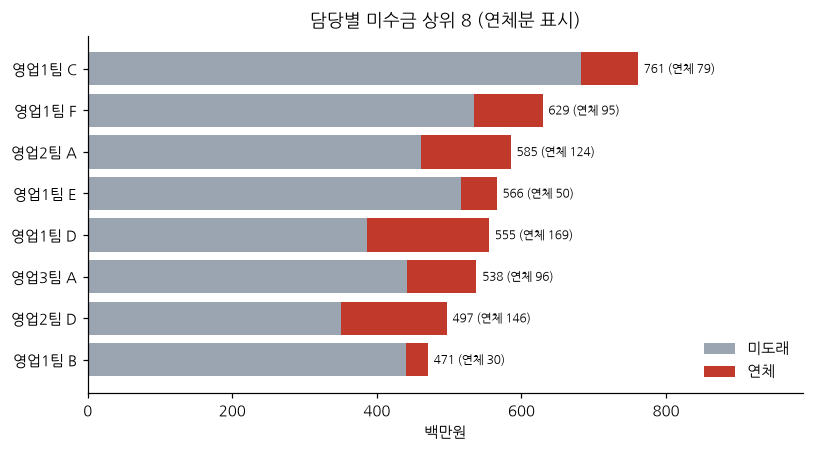

In [8]:
top = d.assign(구분=lambda x: x["연체일"].gt(0).map({True: "연체", False: "미도래"})).pivot_table(
    index="담당", columns="구분", values="금액_원", aggfunc="sum", fill_value=0)
top["합계"] = top.sum(axis=1); top = top.sort_values("합계", ascending=False).head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(top.index, top["미도래"] / 1e6, color="#9aa5b1", label="미도래")
ax.barh(top.index, top["연체"] / 1e6, left=top["미도래"] / 1e6, color="#c0392b", label="연체")
for y, (t, o) in enumerate(zip(top["합계"], top["연체"])):
    ax.text(t / 1e6 + 8, y, f"{t/1e6:,.0f} (연체 {o/1e6:,.0f})", va="center", fontsize=8)
ax.set_xlim(0, top["합계"].max() / 1e6 * 1.3); ax.set_xlabel("백만원"); ax.set_title("담당별 미수금 상위 8 (연체분 표시)"); ax.legend(frameon=False, loc="lower right")
fig.tight_layout(); fig.savefig(CHART_DIR / "d1-4_owner_top.png"); plt.show()

- 영업1팀 C가 761백만원으로 가장 크고, 상위 3명(영업1팀 C·F, 영업2팀 A)이 전체 6,314백만원의 약 31%를 차지합니다.
- 이 8명 중 연체액은 영업1팀 D(169백만원)·영업2팀 D(146백만원)가 크고, 1위 영업1팀 C는 연체 79백만원으로 규모에 비해 낮아 규모 순위와 연체 순위가 다릅니다.

## 다음에 확인할 질문
1. **부도 메모 11건(200백만원)과 90일 초과 9건(163백만원)**의 회수 가능성은 어떤가요? 충당·보험 청구 여부는 사람이 판단해야 하므로, 바이어별(Briost · Falia · Quinasta · Changzhou Wenant · Oroari) 연체일·메모를 근거로 정리해 보면 좋겠습니다.
2. **1–30일 연체 25건(541백만원)**에 붙은 약속 메모(예: '10월 초 송금 약속')가 10월 현재 지켜졌는지 확인할 입금 자료가 있나요? 없으면 새 입금 데이터를 요청해야 합니다.
3. **O/A가 금액의 74.6%이고 바이어 1곳(Xanolin 495백만원)이 크게 차지**하는데, 바이어별 한도 대비 노출은 얼마인가요? 한도 자료가 필요하고, '사후송금'을 O/A로 본 가정도 담당자 확인이 필요합니다.